In [256]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import os
import numpy as np
import pandas as pd
import sys
import pickle
from pathlib import Path
from typing import Tuple
from datetime import datetime
from lifelines.utils import concordance_index
from lifelines import CoxPHFitter

#add path path to data folder using sys.path
sys.path.append('../data_process/')
from data_process import load_dataset
from processors.outcomes import get_first_diagnosis
from helpers import * 
from plots import *
import warnings
warnings.filterwarnings('ignore')


# Plot styling configuration
PLOT_STYLE = {
    'figure.dpi': 150,
    'font.size': 6,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 6,  
    'legend.fontsize': 6,
    'axes.titlesize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.edgecolor': 'k',
    'axes.linewidth': 0.5,
    'axes.grid': False,
    'axes.prop_cycle': plt.cycler(color=sns.husl_palette(h=.7)),
    'figure.figsize': (2, 2),
    'xtick.major.pad': -3,
    'ytick.major.pad': -3
}

plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style="white", font='Arial', rc=PLOT_STYLE)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
DATA_PATH = '/Users/aashnashah/Desktop/ssh_mount/SETPOINT/data/processed/'

mortality_df = pd.read_csv(os.path.join(DATA_PATH, 'mortality.csv'))
diagnosis_df = pd.read_csv(os.path.join(DATA_PATH, 'diagnosis.csv'))
first_diagnosis_df = get_first_diagnosis(diagnosis_df)
measurements_df = pd.read_csv(os.path.join(DATA_PATH, 'body_measurements.csv'))
demo_df = pd.read_csv(os.path.join(DATA_PATH, 'demographics.csv')).drop(columns=['observation_period_start_time'])
cbc_df = pd.read_csv(os.path.join(DATA_PATH, 'cbc_measurements.csv'))

patient_df = demo_df.merge(mortality_df, on='subject_id', how='left')
patient_df['time_of_death'] = pd.to_datetime(patient_df['time_of_death'])
patient_df['days_between_visit_and_death'] = (patient_df['time_of_death'] - pd.to_datetime(patient_df['observation_period_end_time'])).dt.days
display(patient_df.query('days_between_visit_and_death < 0').head(3))

# Mortality Association - Setpoints/CV


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Setpoint'}, xlabel='Code', ylabel='concordance'>,
        <Axes: title={'center': 'CV'}, xlabel='Code', ylabel='concordance'>],
       dtype=object))

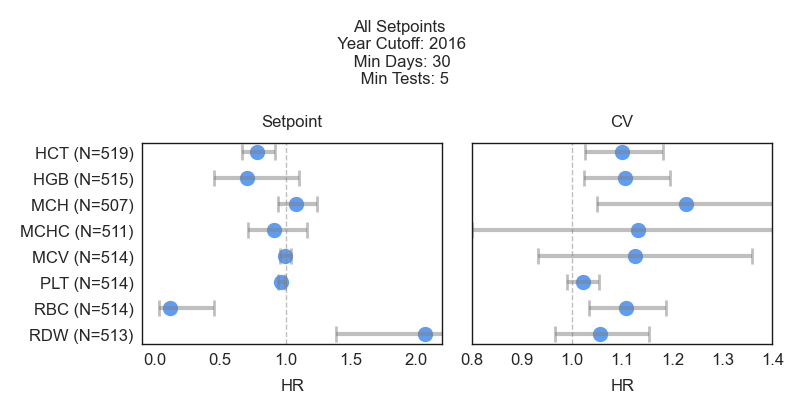

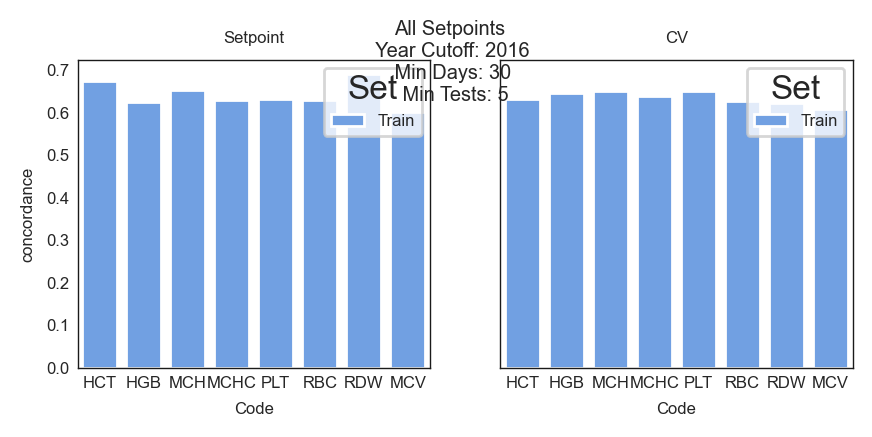

In [262]:
min_days = 30
min_test = 5
year_cutoff = 2016
measurements_df = pd.read_csv(os.path.join(DATA_PATH, 'body_measurements.csv'))

setpoints = pd.read_csv(f'../results/setpoint_calculations/setpoints_gap:{min_days}_tests:{min_test}_year:{year_cutoff}.csv')
df = (setpoints
    .merge(demo_df, on='subject_id', how='left')
    .merge(mortality_df, on='subject_id', how='left'))
df = convert_to_datetime(df) 
df = merge_setpoints_and_measurements(df, measurements_df, 'setpoint_estimation_time')
      
setpoints_2016 = run_cox_analysis(df, 30, 5, 2016, [], split=True)
#setpoints_2016_with_BMI= run_cox_analysis(df, 30, 5, 2016, ['BMI'], use_train_test=False, setpoint_in_interval=True)
#setpoints_2016_BMI_cat = run_cox_analysis(df, 30, 5, 2016, ['BMI_category_Morbid Obesity', 'BMI_category_Obesity', 'BMI_category_Overweight', 'BMI_category_Underweight'], use_train_test=True, setpoint_in_interval=True)

plot_setpoint_hr(setpoints_2016[0], f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
plot_concordance(setpoints_2016[0], f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')

# Mortality Prediction - Boolean Biomarkers 

In [149]:

args = {'min_days': 30, 'min_test': 5, 'year_cutoff': 2016, 'min_time': 365, 'max_time': 365*3, 'event_col': 'time_of_death'}
dfs = {'demo_df': demo_df, 'mortality_df': mortality_df, 'cbc_df': cbc_df, 'measurements_df': measurements_df}

df = process_dataframe(dfs, args)
setpoints_prognosis_2016 = run_interval_cox_analysis(df, biomarker_type='bool', features=[], use_train_test=True, setpoint_in_interval=False)
# setpoints_prognosis_2016_with_BMI = run_interval_cox_analysis(df, biomarker_type='bool', features=['BMI'], use_train_test=True, setpoint_in_interval=False)
# setpoints_prognosis_2016_with_BMI_Category = run_interval_cox_analysis(df, biomarker_type='bool', features=['BMI_category_Morbid Obesity', 'BMI_category_Obesity', 'BMI_category_Overweight', 'BMI_category_Underweight'], use_train_test=True, setpoint_in_interval=True)

In [ ]:

plot_interval_hr(setpoints_prognosis_2016[0], f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
fig, axes = plot_interval_concordance(setpoints_prognosis_2016[1], 
                                   f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
plt.show()


# Mortality Prediction: Absolute Magnitude

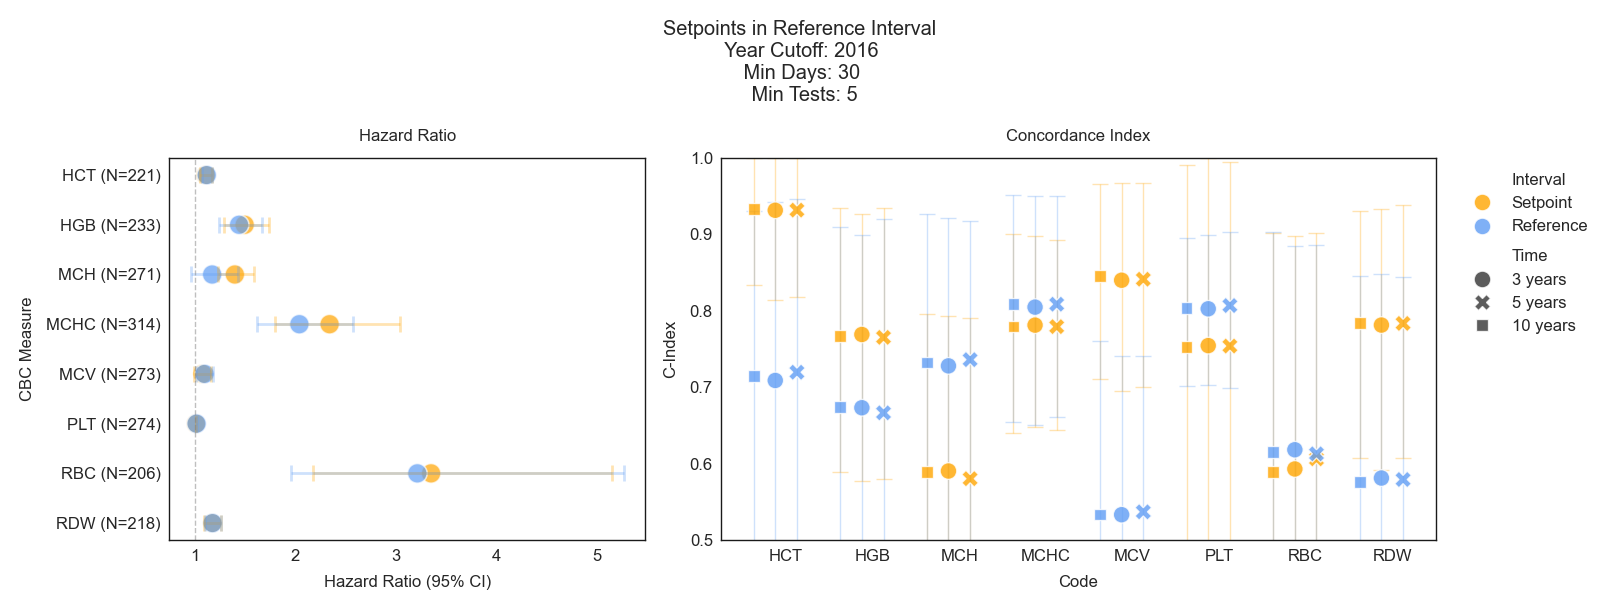

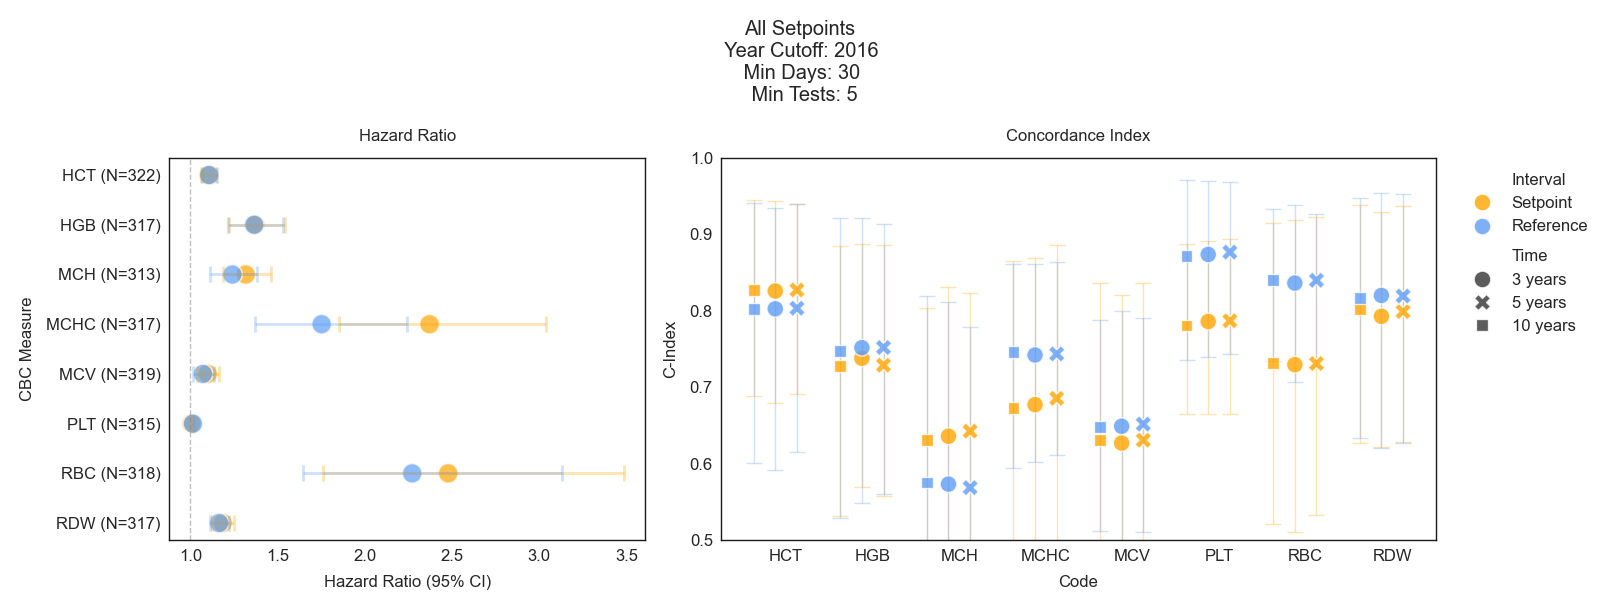

In [260]:
args = {'min_days': 30, 'min_test': 5, 'year_cutoff': 2016, 'min_time': 365, 'max_time': 365*3, 'event_col': 'time_of_death'}
dfs = {'demo_df': demo_df, 'mortality_df': mortality_df, 'cbc_df': cbc_df}
df = process_dataframe(dfs, args)

all_setpoints_prognosis = run_interval_cox_analysis(df, biomarker_type='numeric', features=[], split=True, setpoint_in_interval=True)
ref_setpoints_prognosis = run_interval_cox_analysis(df, biomarker_type='numeric', features=[], split=True, setpoint_in_interval=False)

title = f'Setpoints in Reference Interval \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}'
plot_interval_hr_concordance(all_setpoints_prognosis, title)

title = f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}'
plot_interval_hr_concordance(ref_setpoints_prognosis, title)